# `DeepTrack`
## A 4D extension of Ocetrac for volumetric tracking

### 1. Imports

In [17]:
import sys
import os

from ocetrac.preprocessing.preprocessing import clean_binary, compute_anomalies, threshold_features
from ocetrac.preprocessing.utils import compute_dask_quantile, get_xarray_memory_usage
from ocetrac.DeepTrack import DeepTracker
from ocetrac.DeepTrack import grid, tracker
from ocetrac.DeepTrack import _wrap_longitude
from ocetrac.preprocessing.cesm2_lens_utils import get_ds_var

In [2]:
import gc
import warnings
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore", message=".*decode the variable.*")
warnings.filterwarnings("ignore", message=".*default value for data_vars.*")

### 2. Data loading

This section loads CESM2 Large Ensemble (CESM2-LENS) ocean temperature data for a single ensemble member. The CESM2-LE provides 100 ensemble members spanning 1850-2100.
- Component: `ocn` (ocean model component POP2)
- Temporal resolution: Monthly means

In [3]:
%%time

# Select the ensemble member index
ens_memb_index = 0

# Define variable and component
# 'TEMP' = potential temperature, 'ocn' = ocean component 
# of CESM
var, comp = 'TEMP', 'ocn'

# Construct path to CESM2 Large Ensemble data on NCAR's 
# GLADE filesystem
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'

# Load historical and future projection datasets
ds_hist, ds_fut = get_ds_var(
    directory, 
    var, 
    comp, 
    ens_memb_index)

# Define latitude slice indices
# These correspond to specific grid points 
# in the ocean model's native grid
nlat_low, nlat_high = 26, 328

ds = ds_hist.TEMP.isel(
    z_t  = slice(0, 20), # Select top 20 vertical levels (surface to ~200m)
    nlat = slice(nlat_low, nlat_high), # Select latitude range using indices
).sel(time=slice('1979-01', '2015-01')) # Select time range

ds = ds.compute() # Load data from disk into memory

CPU times: user 27.2 s, sys: 2.28 s, total: 29.4 s
Wall time: 1min 42s


/glade/u/home/cassiacai/.conda/envs/test_ocetrac/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [4]:
# Clean up future dataset to free memory
# ds_fut not needed for current analysis (only using historical period)
del ds_fut

# Force garbage collection to immediately release memory
gc.collect()
print(f"Loaded: {ds.shape}")

Loaded: (433, 20, 302, 320)


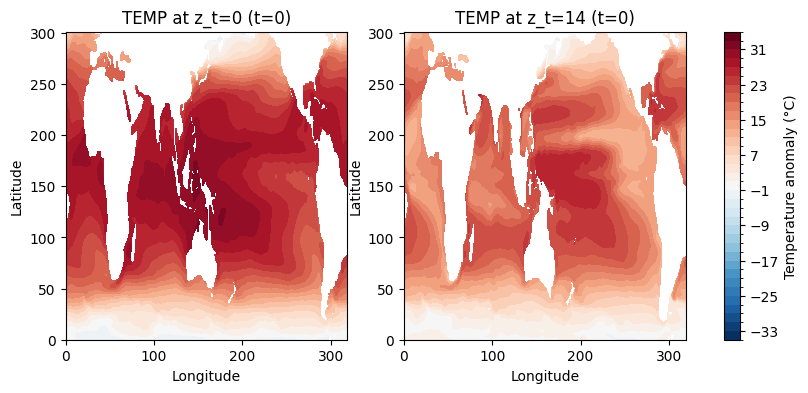

In [5]:
## -------------- Figure of temperature at different z_t
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = ds[0, 0, :, :].plot.contourf(
    ax=ax1,
    levels=36, 
    vmin=-35, 
    vmax=35, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax1.set_title('TEMP at z_t=0 (t=0)', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = ds[0, 14, :, :].plot.contourf(
    ax=ax2,
    levels=36, 
    vmin=-35, 
    vmax=35, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax2.set_title('TEMP at z_t=14 (t=0)', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Temperature anomaly (°C)', fontsize=10)
plt.show()

### 3. Anomaly computation

This preprocessing step is separate from the Ocetrac tracking algorithm. It prepares the temperature field by the trend and seasonality.

This example notebook uses `preprocessing.compute_anomalies`, which fits a 6-coefficient harmonic model per grid cell and returns the residual. `preprocessing.threshold_features` masks values below the 90th percentile.

In [6]:
%%time

anom = compute_anomalies(
    ds)

features, threshold_map = threshold_features(
    anom, 
    q=0.9) # 90th quantile 

print(f"features shape: {features.shape}  ({features.nbytes/1e9:.2f} GB)")

[########################################] | 100% Completed | 57.95 s
[########################################] | 100% Completed | 4.69 sms
features shape: (433, 20, 302, 320)  (6.70 GB)
CPU times: user 1min 8s, sys: 2.63 s, total: 1min 11s
Wall time: 1min 19s


In [7]:
# Subset first 40 timesteps (months) for tutorial
features = features.isel(time=slice(40))

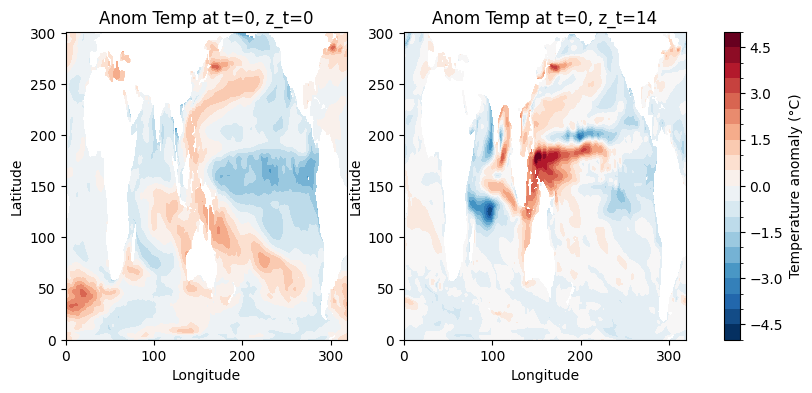

In [8]:
## -------------- Figure of anom temperature at different z_t

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = anom[0, 0, :, :].plot.contourf(
    ax=ax1,
    levels=21, 
    vmin=-5, 
    vmax=5, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax1.set_title('Anom Temp at t=0, z_t=0', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = anom[0, 14, :, :].plot.contourf(
    ax=ax2,
    levels=21, 
    vmin=-5, 
    vmax=5, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax2.set_title('Anom Temp at t=0, z_t=14', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Temperature anomaly (°C)', fontsize=10)

plt.show()

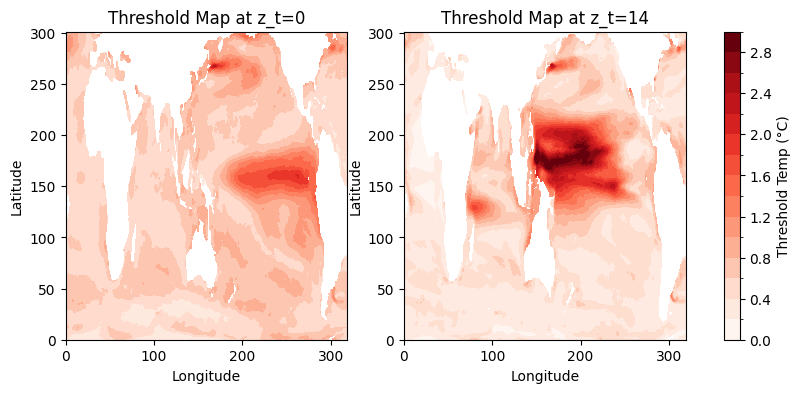

In [9]:
## -------------- Figure of threshold map at different z_t

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = threshold_map[0, :, :].plot.contourf(
    ax=ax1,
    levels=16, 
    vmin=0, 
    vmax=3, 
    cmap='Reds',
    add_colorbar=False
)
ax1.set_title('Threshold Map at z_t=0', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = threshold_map[14, :, :].plot.contourf(
    ax=ax2,
    levels=16, 
    vmin=0, 
    vmax=3, 
    cmap='Reds',
    add_colorbar=False
)
ax2.set_title('Threshold Map at z_t=14', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Threshold Temp (°C)', fontsize=10)

plt.show()

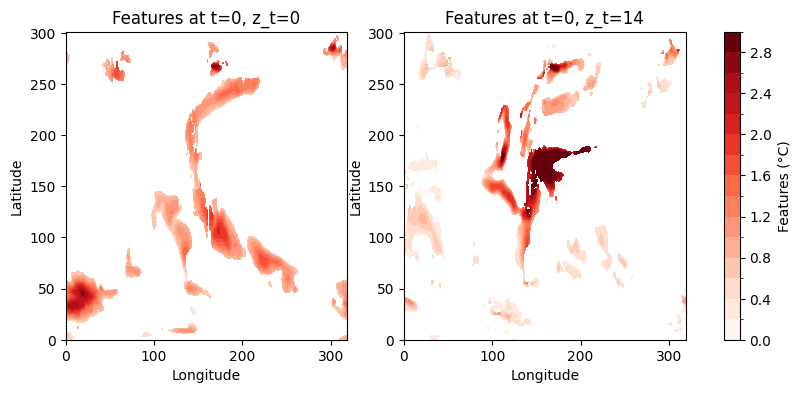

In [10]:
## -------------- Figure of 90% threshold features at different z_t

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = features[0, 0, :, :].plot.contourf(
    ax=ax1,
    levels=16, 
    vmin=0, 
    vmax=3, 
    cmap='Reds',
    add_colorbar=False
)
ax1.set_title('Features at t=0, z_t=0', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = features[0, 14, :, :].plot.contourf(
    ax=ax2,
    levels=16, 
    vmin=0, 
    vmax=3, 
    cmap='Reds',
    add_colorbar=False
)
ax2.set_title('Features at t=0, z_t=14', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Features (°C)', fontsize=10)

plt.show()

### 4. Cell volume

`grid.build_cell_volume` converts TAREA (cm²) × dz (cm) → m³ per voxel. Using POP_grid.

In [11]:
%%time
grid_info   = ds_hist.isel(
    z_t=slice(0, 20), 
    nlat=slice(nlat_low, nlat_high)).sel(
    time=slice('1979-01', '2015-01'))


TAREA = grid_info.TAREA.isel(time=0)
lat = grid_info['TLAT'].values

cell_volume = grid.build_cell_volume(TAREA, 
                                     ds_hist.z_t, 
                                     n_z=20).compute()
cell_vol_np = cell_volume.values

print("cell_volume shape:", cell_volume.shape)
print("lat shape        :", lat.shape)

cell_volume shape: (20, 302, 320)
lat shape        : (302, 320)
CPU times: user 187 ms, sys: 28.1 ms, total: 215 ms
Wall time: 267 ms


## DeepTrack components

### Step 1 — Morphological cleaning

`preprocessing.clean_binary` runs close→open per (t, z) slice. Closing fills holes and bridges small gaps; opening removes tiny residual blobs. `radius` controls the disk size.

The input field is binarised and a close→open morphological sequence is applied 
independently to each ``(lat, lon)`` slice using a circular disk structuring element. 
Critically, the padding is applied in ``wrap`` mode along both spatial axes — this means 
the operation is **cyclo-symmetric**: features near the edges of the domain are treated 
as if the grid wraps around periodically, avoiding artefacts at the longitude boundary. 
The ocean mask is applied after cleaning to zero out land and sea-ice cells.
 
**Closing** (dilation followed by erosion)
   Fills small interior holes and bridges narrow gaps within a feature, maintaining 
   spatial coherence across nearby regions that belong to the same event.
 
**Opening** (erosion followed by dilation)
   Removes isolated pixels and residual artefacts introduced by closing, smoothing 
   feature boundaries and eliminating physically spurious detections.
 
The structuring element radius ``R`` controls the spatial scale of filtering. A larger 
radius merges nearby features and fills larger gaps; a smaller radius preserves 
fine-scale structure at the risk of retaining noise. For 0.25° resolution data:
 
- ``R`` = 4–6 grid cells (1–1.5°): Preserves smaller-scale features while removing noise
- ``R`` = 6–8 grid cells (1.5–2°): Emphasises larger, more coherent structures
- ``R`` > 8 grid cells: May merge distinct features or fail to identify valid objects
 
For higher-resolution data, ``R`` should be scaled proportionally.

In [12]:
%%time
RADIUS = 3

binary_clean = clean_binary(
    features, 
    radius=RADIUS, 
    positive=True).compute()

CPU times: user 4.2 s, sys: 4.92 ms, total: 4.2 s
Wall time: 4.38 s


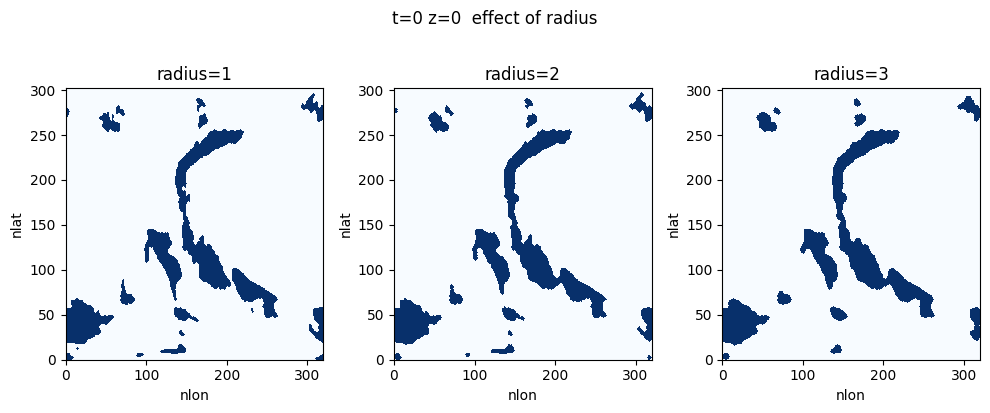

In [13]:
# Figure - Compare radii
t_check, z_check = 0, 0
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, r in zip(axes, [1, 2, 3]):
    c = clean_binary(features, radius=r, positive=True).compute()
    ax.pcolormesh(c.values[t_check, z_check].astype(int), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'radius={r}'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.suptitle(f't={t_check} z={z_check}  effect of radius', y=1.02)
plt.tight_layout(); plt.show(); plt.close()

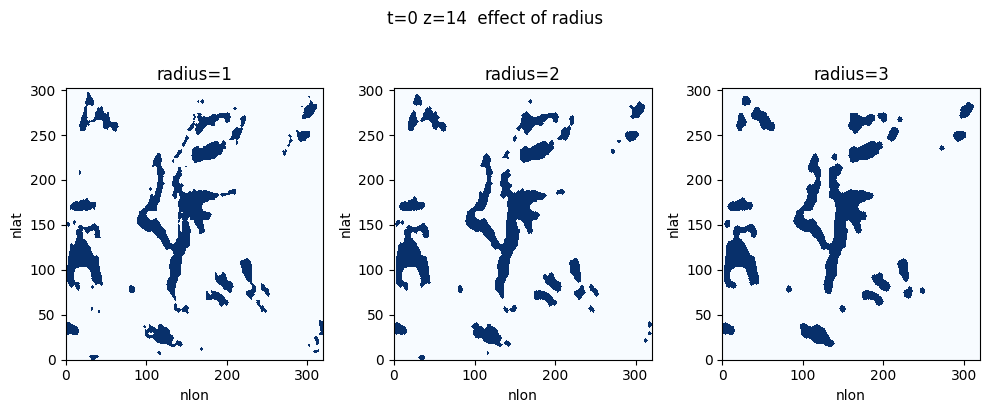

In [14]:
# Figure - Compare radii
t_check, z_check = 0, 14
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, r in zip(axes, [1, 2, 3]):
    c = clean_binary(features, radius=r, positive=True).compute()
    ax.pcolormesh(c.values[t_check, z_check].astype(int), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'radius={r}'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.suptitle(f't={t_check} z={z_check}  effect of radius', y=1.02)
plt.tight_layout(); plt.show(); plt.close()

### Step 2 — 2-D connected-component labelling

`tracker.label_2d_stack` runs `scipy.ndimage.label` on each (t, z) slice. Background = 0.

Each ``(time, depth)`` slice is labelled independently using 2-D connected-component 
labelling. This assigns a unique integer label to each contiguous blob of active cells within 
a single depth level and timestep.

In [15]:
%%time
labeled_2d = tracker.label_2d_stack(binary_clean)

CPU times: user 314 ms, sys: 65 µs, total: 314 ms
Wall time: 357 ms


2-D blobs at surface — mean: 15.1  min: 8  max: 22


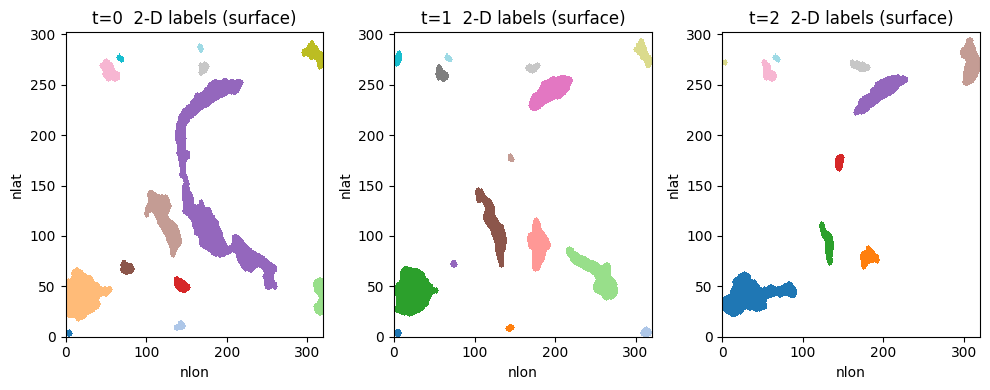

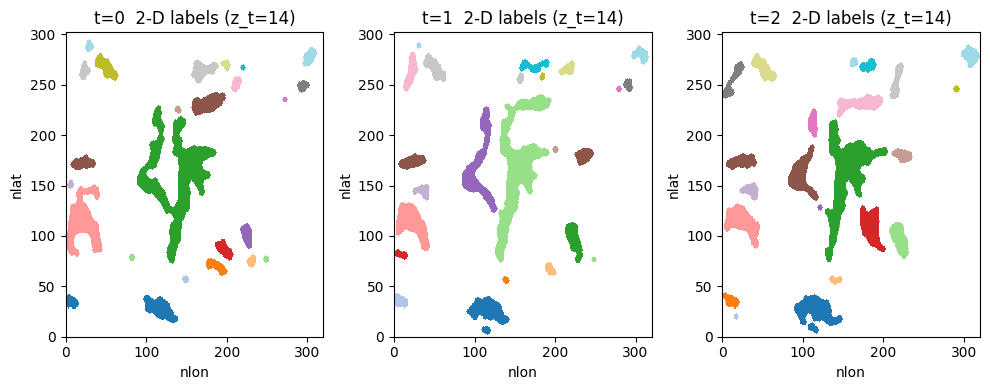

In [16]:
n_surf = [len(np.unique(labeled_2d.values[t, 0])) - 1 for t in range(labeled_2d.shape[0])]
print(f"2-D blobs at surface — mean: {np.mean(n_surf):.1f}  min: {min(n_surf)}  max: {max(n_surf)}")

labeled_2d_nan = xr.where(labeled_2d == 0, np.nan, labeled_2d)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.pcolormesh(labeled_2d_nan.values[i, 0], cmap='tab20')
    ax.set_title(f't={i}  2-D labels (surface)'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.tight_layout(); plt.show(); plt.close()

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.pcolormesh(labeled_2d_nan.values[i, 14], cmap='tab20')
    ax.set_title(f't={i}  2-D labels (z_t=14)'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.tight_layout(); plt.show(); plt.close()

In [18]:
labeled_2d_np = _wrap_longitude(labeled_2d.values)
labeled_2d = xr.DataArray(labeled_2d_np, dims=labeled_2d.dims, coords=labeled_2d.coords)

### Step 3 — 2-D area filter

`tracker.filter_area_2d_global_depth` drops small blobs using threshold = `max(min_area_cells, percentile(all_areas_at_z, q))` computed across ALL timesteps per depth level.

Small 2-D blobs are removed based on a combined absolute and relative area threshold 
(``min_area_cells`` and ``min_quantile``). The surviving blobs are then relabelled and 
connected vertically across depth layers using a 3-D structuring element to form 
objects. Vertical connectivity can be toggled with the ``connect_z`` parameter.

In [19]:
%%time

# absolute floor: blobs with fewer than this many grid 
# cells are removed, regardless of percentile
MIN_AREA_CELLS = 200
# also drop blobs below the 25th percentile of the area 
# distribution
MIN_QUANTILE   = 0.25

filtered_np = tracker.filter_area_2d_global_depth(
    labeled_2d.values,
    min_quantile   = MIN_QUANTILE,
    min_area_cells = MIN_AREA_CELLS,
)

CPU times: user 1.01 s, sys: 4.09 ms, total: 1.02 s
Wall time: 1.06 s


Total 2-D blobs before: 15690
After area filter     : 7317  (removed 8373)


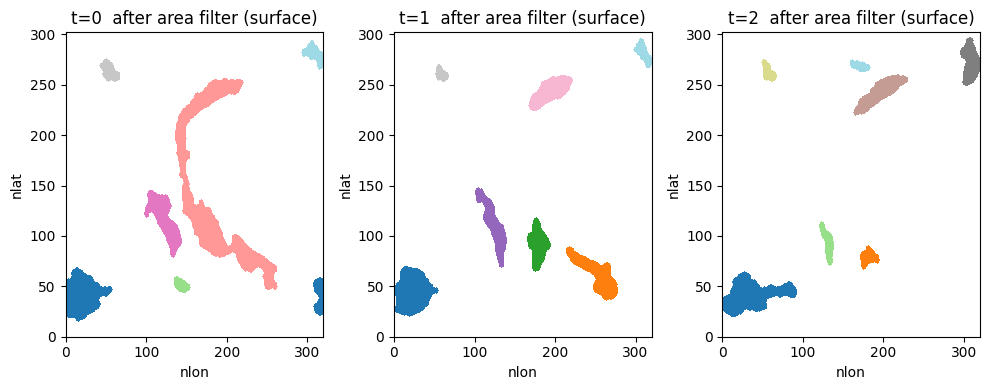

<Figure size 640x480 with 0 Axes>

In [20]:
n_before = sum(len(np.unique(labeled_2d.values[t,z]))-1
               for t in range(labeled_2d.shape[0]) for z in range(labeled_2d.shape[1]))
n_after  = sum(len(np.unique(filtered_np[t,z][filtered_np[t,z]>0]))
               for t in range(filtered_np.shape[0]) for z in range(filtered_np.shape[1]))
print(f"Total 2-D blobs before: {n_before}")
print(f"After area filter     : {n_after}  (removed {n_before - n_after})")

filtered_np_nan = xr.where(filtered_np == 0, np.nan, filtered_np)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.pcolormesh(filtered_np_nan[i, 0], cmap='tab20')
    ax.set_title(f't={i}  after area filter (surface)'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.tight_layout(); plt.show(); plt.close()

for i, ax in enumerate(axes):
    ax.pcolormesh(filtered_np_nan[i, 14], cmap='tab20')
    ax.set_title(f't={i}  after area filter (z_t=14)'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.tight_layout(); plt.show(); plt.close()

### Step 4 — 3-D depth connectivity

`tracker.build_3d_objects` runs `scipy.ndimage.label` in 3D on each timestep's (z, nlat, nlon) volume using an anisotropic structuring element: full 8-connectivity in (lat, lon), face-only in z. 

In [21]:
%%time

CONNECT_Z = True

# Relabel per (t,z) so IDs are compact before 3-D labelling
relabeled_np = np.zeros_like(
    filtered_np, 
    dtype=int)

for t in range(filtered_np.shape[0]):
    for z in range(filtered_np.shape[1]):
        relabeled_np[t, z] = tracker.relabel_2d(filtered_np[t, z])

struct = grid.make_anisotropic_struct(
    connect_xy=True, 
    connect_z=CONNECT_Z)

labeled_3d = tracker.build_3d_objects(
    relabeled_np, 
    struct)

labeled_3d = _wrap_longitude(labeled_3d) # merge date-line objects

CPU times: user 955 ms, sys: 160 ms, total: 1.11 s
Wall time: 1.16 s


connect_z=True
3-D objects per timestep — mean: 20.7  min: 13  max: 30
Total (sum across t)           : 827


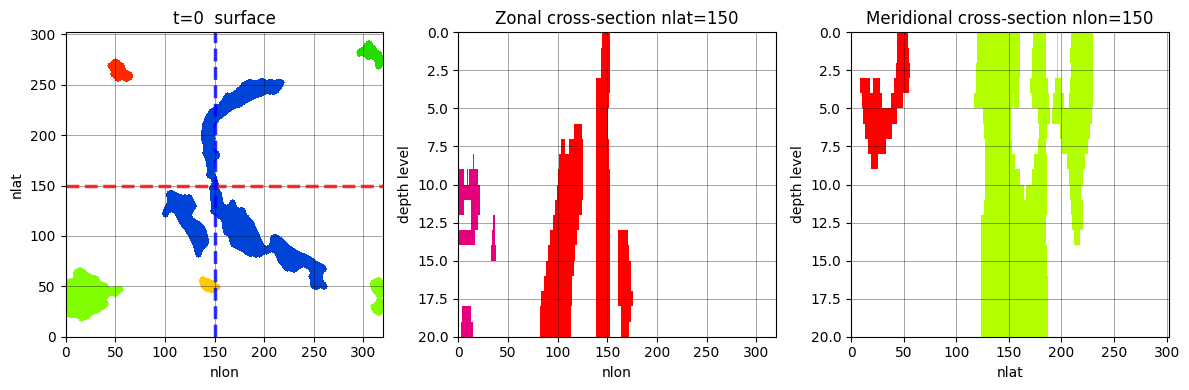

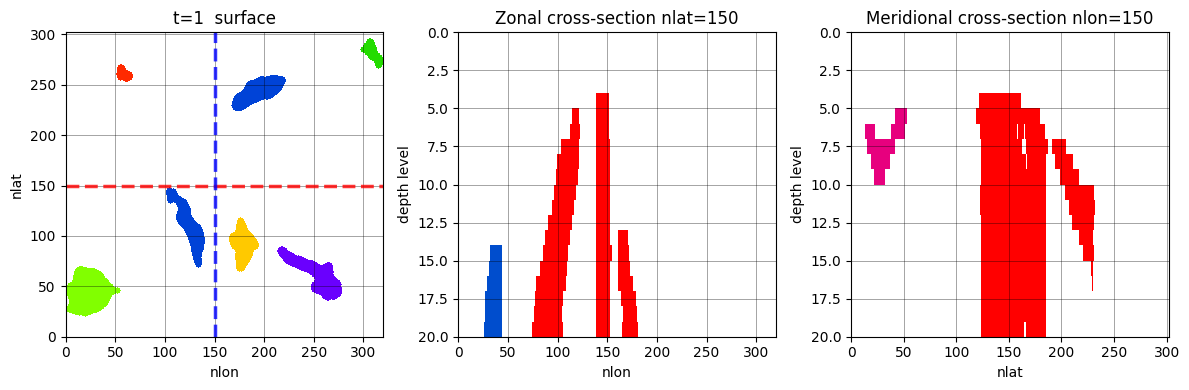

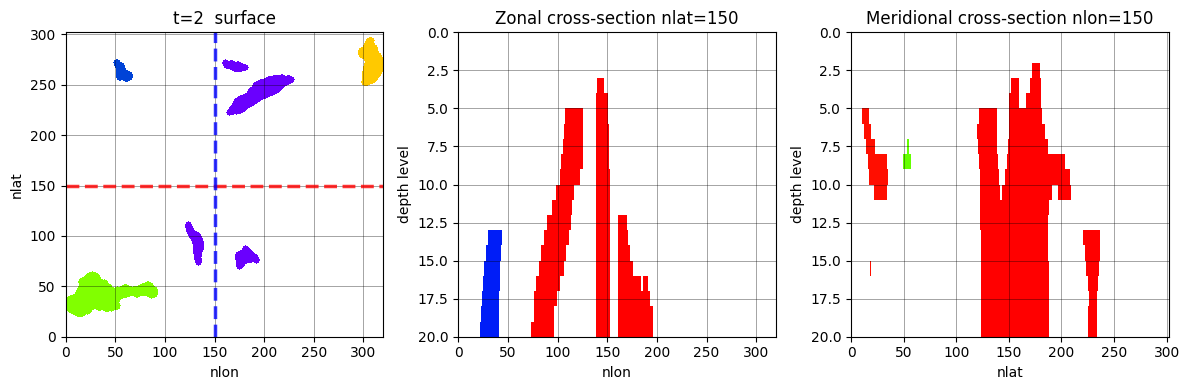

In [22]:
n_3d_per_t = [len(np.unique(labeled_3d[t][labeled_3d[t] > 0])) for t in range(labeled_3d.shape[0])]
print(f"connect_z={CONNECT_Z}")
print(f"3-D objects per timestep — mean: {np.mean(n_3d_per_t):.1f}  "
      f"min: {min(n_3d_per_t)}  max: {max(n_3d_per_t)}")
print(f"Total (sum across t)           : {sum(n_3d_per_t)}")

labeled_3d_nan = xr.where(labeled_3d == 0, np.nan, labeled_3d)

for t_check in range(3):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].pcolormesh(labeled_3d_nan[t_check, 0], vmin=0, vmax=25, cmap='prism')
    axes[0].axhline(y=150, color='red', linewidth=2.5, linestyle='--', alpha=0.8, label='Zonal section (nlat=150)')
    axes[0].axvline(x=150, color='blue', linewidth=2.5, linestyle='--', alpha=0.8, label='Meridional section (nlon=150)')
    axes[0].set_title(f't={t_check}  surface'); axes[0].set_xlabel('nlon'); axes[0].set_ylabel('nlat')
    axes[0].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    axes[1].pcolormesh(labeled_3d_nan[t_check, :, 150, :], vmax=31, cmap='prism')
    axes[1].invert_yaxis(); axes[1].set_title('Zonal cross-section nlat=150')
    axes[1].set_xlabel('nlon'); axes[1].set_ylabel('depth level')
    axes[1].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    axes[2].pcolormesh(labeled_3d_nan[t_check, :, :, 150], vmax=31, cmap='prism')
    axes[2].invert_yaxis(); axes[2].set_title('Meridional cross-section nlon=150')
    axes[2].set_xlabel('nlat'); axes[2].set_ylabel('depth level')
    axes[2].grid(True, color='k', linewidth=0.5, alpha=0.5)
    plt.tight_layout(); plt.show(); plt.close()

### Step 5 — Global volume filter

`tracker.filter_preserve_labels_global` drops the bottom `frac_filter` fraction of all 3-D objects by voxel count summed across ALL timesteps.

3-D objects are ranked globally by voxel count and the smallest fraction (``frac_filter``) 
are discarded. This removes spurious small-scale detections before tracking begins.

In [26]:
%%time

FRAC_FILTER = 0.25

filtered_labels = tracker.filter_preserve_labels_global(
    labeled_3d, 
    frac=FRAC_FILTER)

CPU times: user 25.6 s, sys: 282 ms, total: 25.9 s
Wall time: 28.6 s


In [27]:
n_pre_per_t = [len(np.unique(filtered_labels[t][filtered_labels[t] > 0])) for t in range(filtered_labels.shape[0])]
dropped     = sum(n_3d_per_t) - sum(n_pre_per_t)
print(f"After prefilter — mean per t: {np.mean(n_pre_per_t):.1f}  total: {sum(n_pre_per_t)}")
print(f"Dropped {dropped} objects ({dropped / max(sum(n_3d_per_t),1) * 100:.1f} %)")

After prefilter — mean per t: 19.8  total: 793
Dropped 34 objects (4.1 %)


In [28]:
filtered_labels_nan = xr.where(filtered_labels == 0, np.nan, filtered_labels)

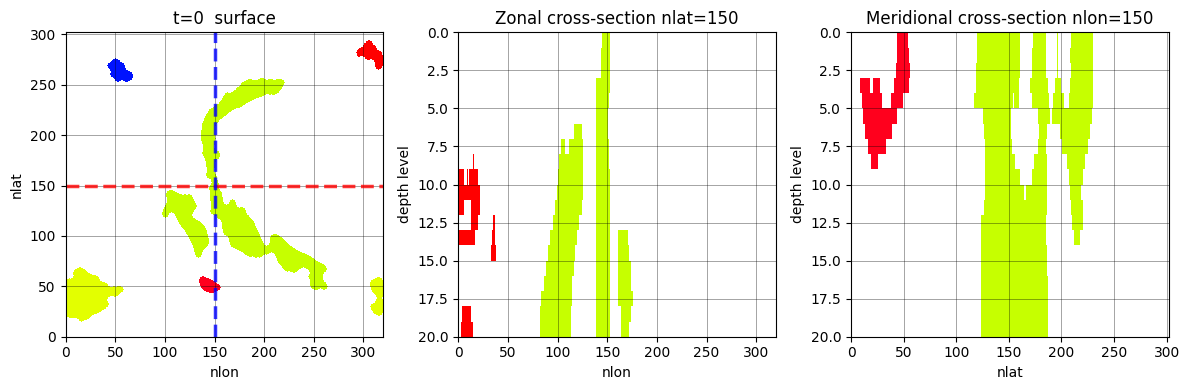

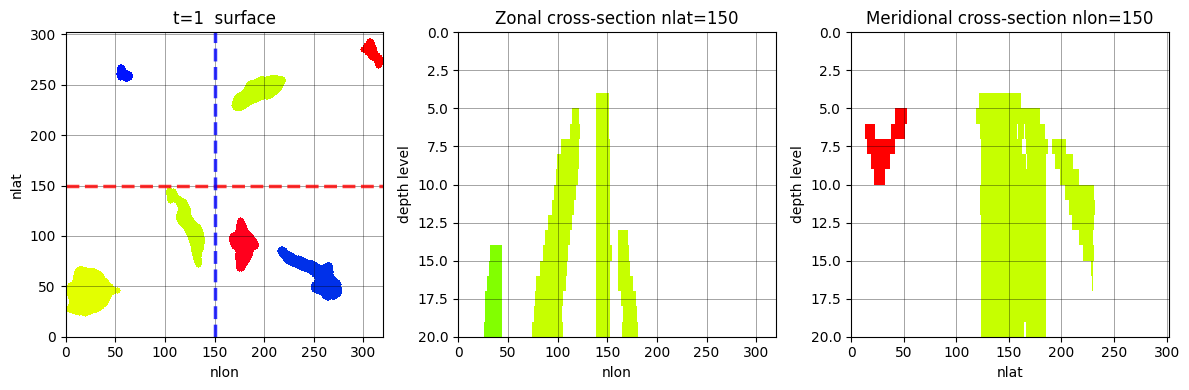

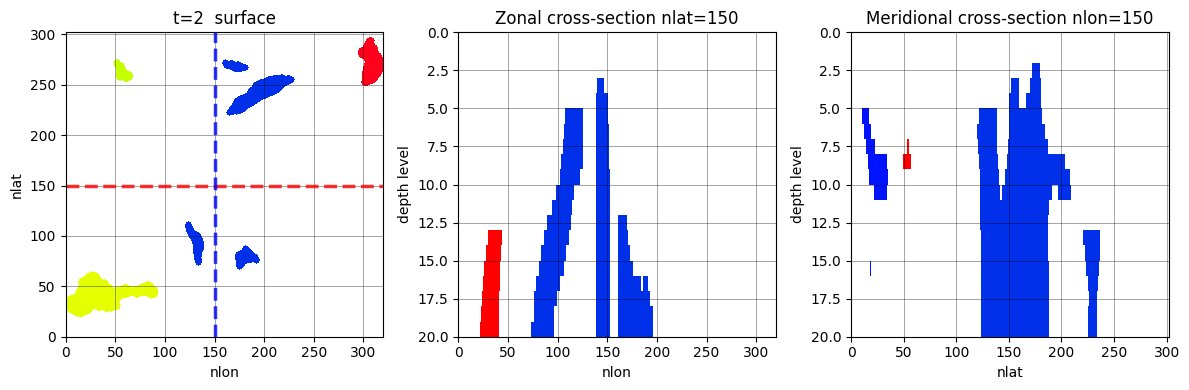

In [29]:
for t_check in range(3):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].pcolormesh(filtered_labels_nan[t_check, 0], vmin=0, vmax=31, cmap='prism')
    axes[0].axhline(y=150, color='red', linewidth=2.5, linestyle='--', alpha=0.8, label='Zonal section (nlat=150)')
    axes[0].axvline(x=150, color='blue', linewidth=2.5, linestyle='--', alpha=0.8, label='Meridional section (nlon=150)')
    axes[0].set_title(f't={t_check}  surface'); axes[0].set_xlabel('nlon'); axes[0].set_ylabel('nlat')
    axes[0].grid(True, color='k', linewidth=0.5, alpha=0.5)
    axes[1].pcolormesh(filtered_labels_nan[t_check, :, 150, :], vmin=0, vmax=31, cmap='prism')
    axes[1].invert_yaxis(); axes[1].set_title('Zonal cross-section nlat=150')
    axes[1].set_xlabel('nlon'); axes[1].set_ylabel('depth level')
    axes[1].grid(True, color='k', linewidth=0.5, alpha=0.5)
    axes[2].pcolormesh(filtered_labels_nan[t_check, :, :, 150], vmin=0, vmax=31, cmap='prism')
    axes[2].invert_yaxis(); axes[2].set_title('Meridional cross-section nlon=150')
    axes[2].set_xlabel('nlat'); axes[2].set_ylabel('depth level')
    axes[2].grid(True, color='k', linewidth=0.5, alpha=0.5)
    plt.tight_layout(); plt.show(); plt.close()

### Step 6 — Containment tracking with lineage preservation

`tracker.track_objects_with_splitting` links objects across time using:

```
score = max(|A∩B|/|A|, |A∩B|/|B|)
```

Dividing by the smaller object means a fragment fully contained in a parent scores 1.0, correctly linking split children. Each current object independently picks the parent with the **smallest original ID** above `contain_thresh`. Unmatched objects become new events.

Objects are linked across consecutive timesteps using a containment score that combines 
spatial voxel overlap with physical cell volume (when ``cell_volume`` is provided). Two 
objects are linked if their containment score exceeds ``contain_thresh``. The ``alpha`` 
parameter controls the weighting between voxel-based and volume-based containment 
(``0`` = volume only, ``1`` = voxel only). The tracker preserves lineage when objects split 
or merge.

In [32]:
%%time

CONTAIN_THRESH = 0.3
ALPHA = 0.5

depth_connected = filtered_labels

tracked, origin_map = tracker.track_objects_with_splitting(
    depth_connected,
    volume_weights  = cell_vol_np,
    contain_thresh  = CONTAIN_THRESH,
    alpha           = ALPHA,
    plot_results    = False,
)

CPU times: user 16.9 s, sys: 75.3 ms, total: 17 s
Wall time: 19.2 s


In [33]:
tracked_nan = xr.where(tracked == 0, np.nan, tracked)

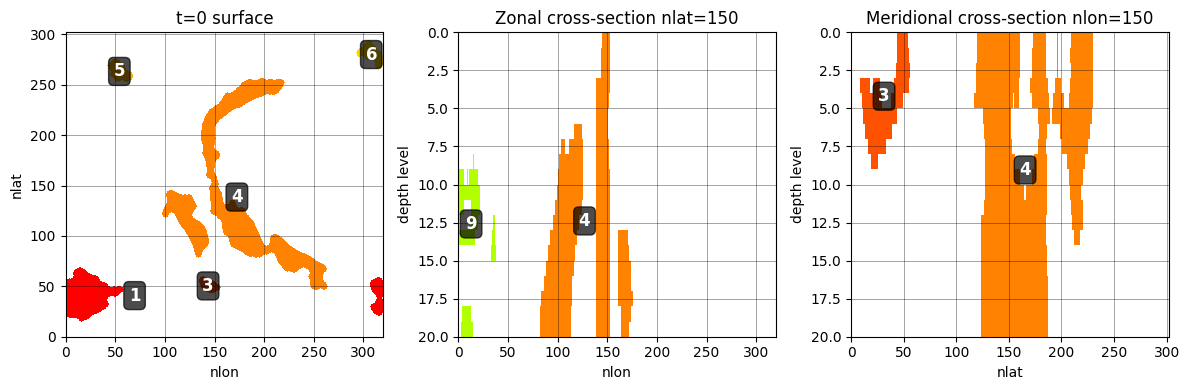

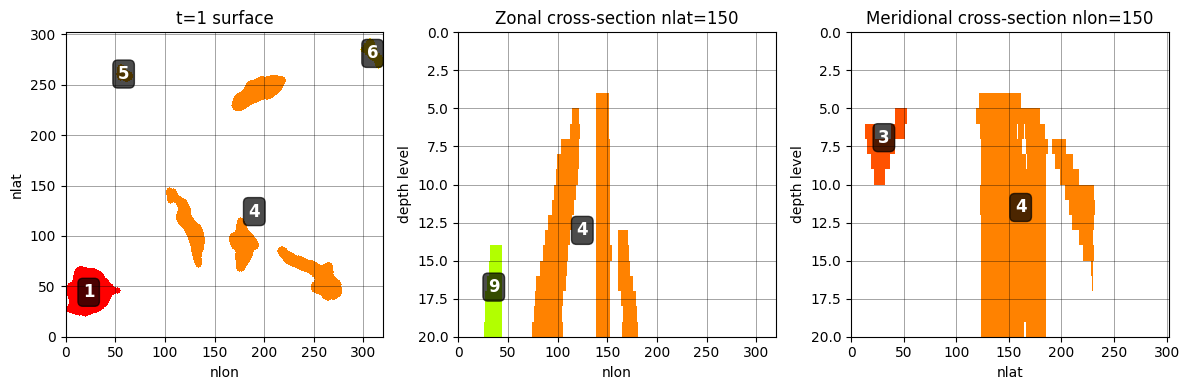

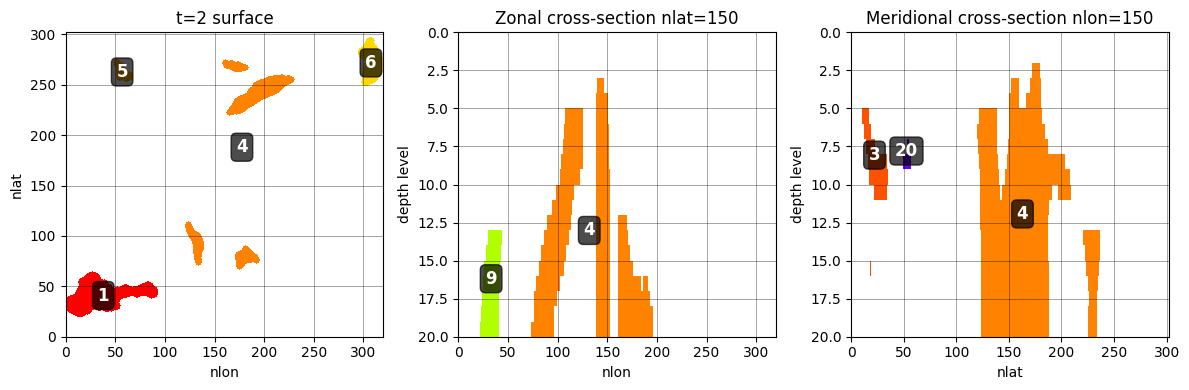

In [45]:
for t_check in range(3):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # ===== SURFACE PLOT =====
    surface_data = tracked_nan[t_check, 0]
    im0 = axes[0].pcolormesh(surface_data, vmin=0, vmax=256, cmap='prism')
    axes[0].set_title(f't={t_check} surface')
    axes[0].set_xlabel('nlon')
    axes[0].set_ylabel('nlat')
    axes[0].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object on surface
    unique_ids = np.unique(surface_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (surface_data == obj_id)
        if mask.any():
            # Get centroid of the object
            y_center, x_center = np.mean(np.where(mask), axis=1)
            # Get the actual object label
            obj_label = int(obj_id)
            axes[0].text(x_center, y_center, str(obj_label), 
                        color='white', fontsize=12, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # ===== ZONAL CROSS-SECTION =====
    zonal_data = tracked_nan[t_check, :, 150, :]
    im1 = axes[1].pcolormesh(zonal_data, vmin=0, vmax=256, cmap='prism')
    axes[1].invert_yaxis()
    axes[1].set_title('Zonal cross-section nlat=150')
    axes[1].set_xlabel('nlon')
    axes[1].set_ylabel('depth level')
    axes[1].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object in zonal section
    unique_ids = np.unique(zonal_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (zonal_data == obj_id)
        if mask.any():
            # Get centroid (depth, lon)
            z_center, x_center = np.mean(np.where(mask), axis=1)
            obj_label = int(obj_id)
            axes[1].text(x_center, z_center, str(obj_label), 
                        color='white', fontsize=12, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # ===== MERIDIONAL CROSS-SECTION =====
    merid_data = tracked_nan[t_check, :, :, 150]
    im2 = axes[2].pcolormesh(merid_data, vmin=0, vmax=256, cmap='prism')
    axes[2].invert_yaxis()
    axes[2].set_title('Meridional cross-section nlon=150')
    axes[2].set_xlabel('nlat')
    axes[2].set_ylabel('depth level')
    axes[2].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object in meridional section
    unique_ids = np.unique(merid_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (merid_data == obj_id)
        if mask.any():
            # Get centroid (depth, lat)
            z_center, y_center = np.mean(np.where(mask), axis=1)
            obj_label = int(obj_id)
            axes[2].text(y_center, z_center, str(obj_label), 
                        color='white', fontsize=12, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
        
    plt.tight_layout()
    plt.show()
    plt.close()

### Dropout summary

In [37]:
n_2d    = sum(len(np.unique(labeled_2d.values[t, z])) - 1
              for t in range(labeled_2d.shape[0])
              for z in range(labeled_2d.shape[1]))
n_3d    = sum(n_3d_per_t)

n_before_wrap = n_3d
labeled_3d    = _wrap_longitude(labeled_3d)
n_wrap        = sum(len(np.unique(labeled_3d[t][labeled_3d[t] > 0]))
                    for t in range(labeled_3d.shape[0]))

n_pre   = sum(n_pre_per_t)
n_final = len(np.unique(tracked_nan.data)) - 1

print(f"2-D blobs (all t, all z)   : {n_2d:>6}")
print(f"After 3-D labelling        : {n_3d:>6}  (area filter removed small blobs)")
print(f"After date-line wrap       : {n_wrap:>6}  (merged {n_before_wrap - n_wrap})")
print(f"After global filter        : {n_pre:>6}  (dropped {n_wrap - n_pre})")
print(f"After containment tracking : {n_final}")

2-D blobs (all t, all z)   :  15690
After 3-D labelling        :    827  (area filter removed small blobs)
After date-line wrap       :    827  (merged 0)
After global filter        :    793  (dropped 34)
After containment tracking : 243


# OR RUN EVERYTHING VIA DeepTracker

The `DeepTracker` class wraps the entire pipeline in one call.

In [36]:
%%time

tracker = DeepTracker(
    features,
    radius         = 3,
    min_area_cells = 200,
    min_quantile   = 0.25,
    contain_thresh = 0.3,
    alpha          = 0.5,
    frac_filter    = 0.25,
    connect_z      = True,
    positive       = True,
    n_z            = 20,
    wrap_lon       = True,   # <-- add this
)
result_full = tracker.run(cell_volume=cell_vol_np)
tracker.summary()

Step 1 · morphological cleaning …
    fraction flagged warm = 0.0899  (OK)
Step 2 · 2-D connected-component labelling …
Step 2b · 2-D longitude wrap
    merged 0 date-line objects  (35 → 35)
    surface blobs — mean=14.1  min=7  max=20
Step 3a · area filtering …
    2-D blobs: 15,690 → 7,317  (removed 8,373)
Step 3b · 3-D depth connectivity …
Step 3c · 3-D longitude wrap
    merged 23 date-line objects  (850 → 827)
    3-D objects/timestep — mean=20.7  min=13  max=30  total=827
Step 4 · global volume filter …
    3-D objects: 827 → 793  (removed 34)
Step 5 · containment tracking …
    unique event IDs assigned: 243
Step 6 · wrapping result …
    final events: 243
DeepTracker — Result Summary
  Input shape    : (40, 20, 302, 320)
  Tracked events : 243
  Duration  min/median/max : 1 / 1 / 40
    >=  1 ts : 243
    >=  3 ts : 46
    >=  6 ts : 14
    >= 12 ts : 6

  Parameters:
    radius           = 3
    min_area_cells   = 200
    min_quantile     = 0.25
    frac_filter      = 0.25
   

In [38]:
result_xr = xr.DataArray(
    result_full, 
    dims=features.dims, 
    coords=features.coords,
    name='events_tracked')
# result_xr.to_netcdf('deeptrack_events.nc')

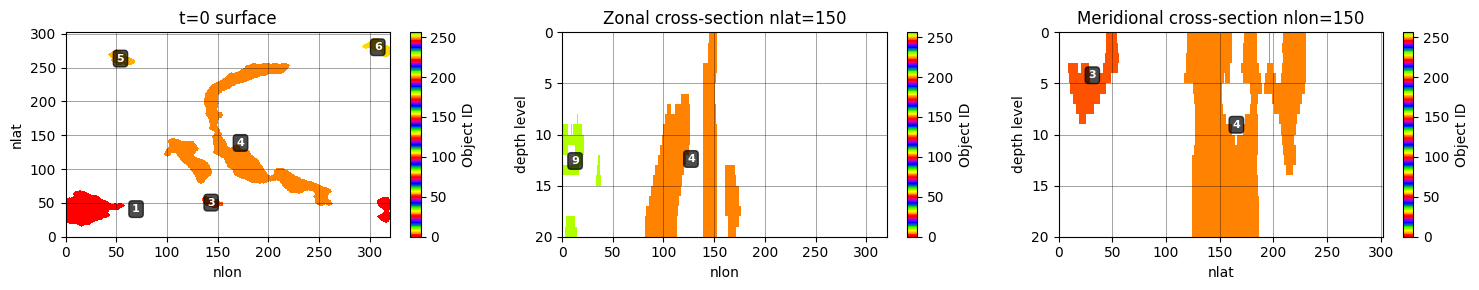

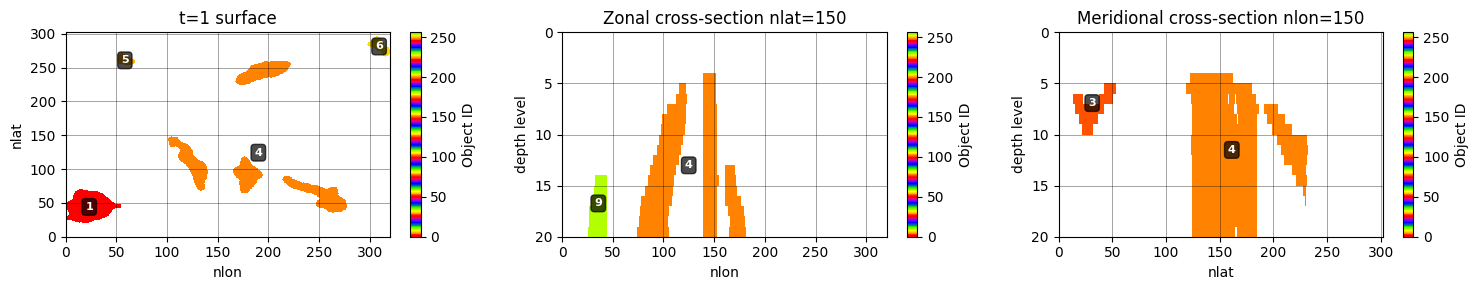

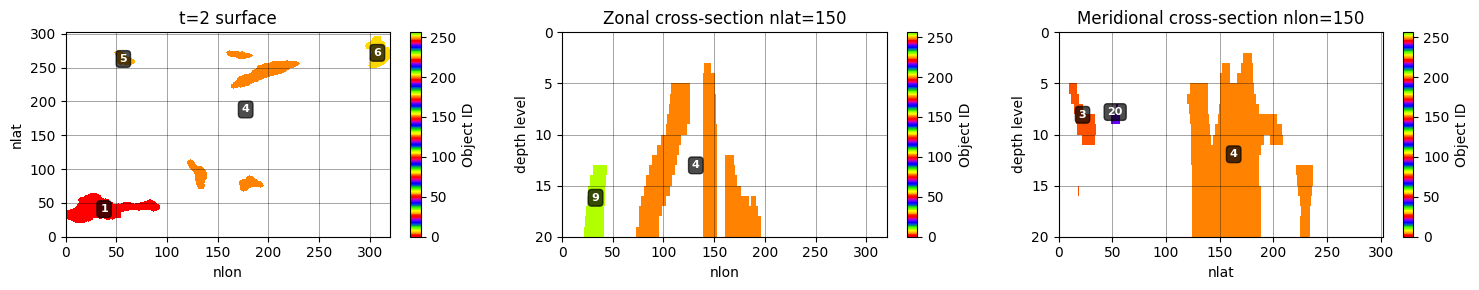

In [39]:
for t_check in range(3):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    
    # ===== SURFACE PLOT =====
    surface_data = result_xr[t_check, 0]
    im0 = axes[0].pcolormesh(surface_data, vmin=0, vmax=256, cmap='prism')
    axes[0].set_title(f't={t_check} surface')
    axes[0].set_xlabel('nlon')
    axes[0].set_ylabel('nlat')
    axes[0].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object on surface
    unique_ids = np.unique(surface_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (surface_data == obj_id)
        if mask.any():
            # Get centroid of the object
            y_center, x_center = np.mean(np.where(mask), axis=1)
            # Get the actual object label
            obj_label = int(obj_id)
            axes[0].text(x_center, y_center, str(obj_label), 
                        color='white', fontsize=8, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # ===== ZONAL CROSS-SECTION =====
    zonal_data = result_xr[t_check, :, 150, :]
    im1 = axes[1].pcolormesh(zonal_data, vmin=0, vmax=256, cmap='prism')
    axes[1].invert_yaxis()
    axes[1].set_title('Zonal cross-section nlat=150')
    axes[1].set_xlabel('nlon')
    axes[1].set_ylabel('depth level')
    axes[1].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object in zonal section
    unique_ids = np.unique(zonal_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (zonal_data == obj_id)
        if mask.any():
            # Get centroid (depth, lon)
            z_center, x_center = np.mean(np.where(mask), axis=1)
            obj_label = int(obj_id)
            axes[1].text(x_center, z_center, str(obj_label), 
                        color='white', fontsize=8, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # ===== MERIDIONAL CROSS-SECTION =====
    merid_data = result_xr[t_check, :, :, 150]
    im2 = axes[2].pcolormesh(merid_data, vmin=0, vmax=256, cmap='prism')
    axes[2].invert_yaxis()
    axes[2].set_title('Meridional cross-section nlon=150')
    axes[2].set_xlabel('nlat')
    axes[2].set_ylabel('depth level')
    axes[2].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object in meridional section
    unique_ids = np.unique(merid_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (merid_data == obj_id)
        if mask.any():
            # Get centroid (depth, lat)
            z_center, y_center = np.mean(np.where(mask), axis=1)
            obj_label = int(obj_id)
            axes[2].text(y_center, z_center, str(obj_label), 
                        color='white', fontsize=8, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    plt.colorbar(im0, ax=axes[0], label='Object ID')
    plt.colorbar(im1, ax=axes[1], label='Object ID')
    plt.colorbar(im2, ax=axes[2], label='Object ID')
    
    plt.tight_layout()
    plt.show()
    plt.close()

# Plotting 3D plots of events

In [40]:
from ocetrac.plotting.DeepTrack_plot_utils import plot_3d_labeled_feature


Plotting feature 5 at time 0
Applied Gaussian smoothing (sigma=0.5)
Extracted surface: 3167 vertices, 6110 faces


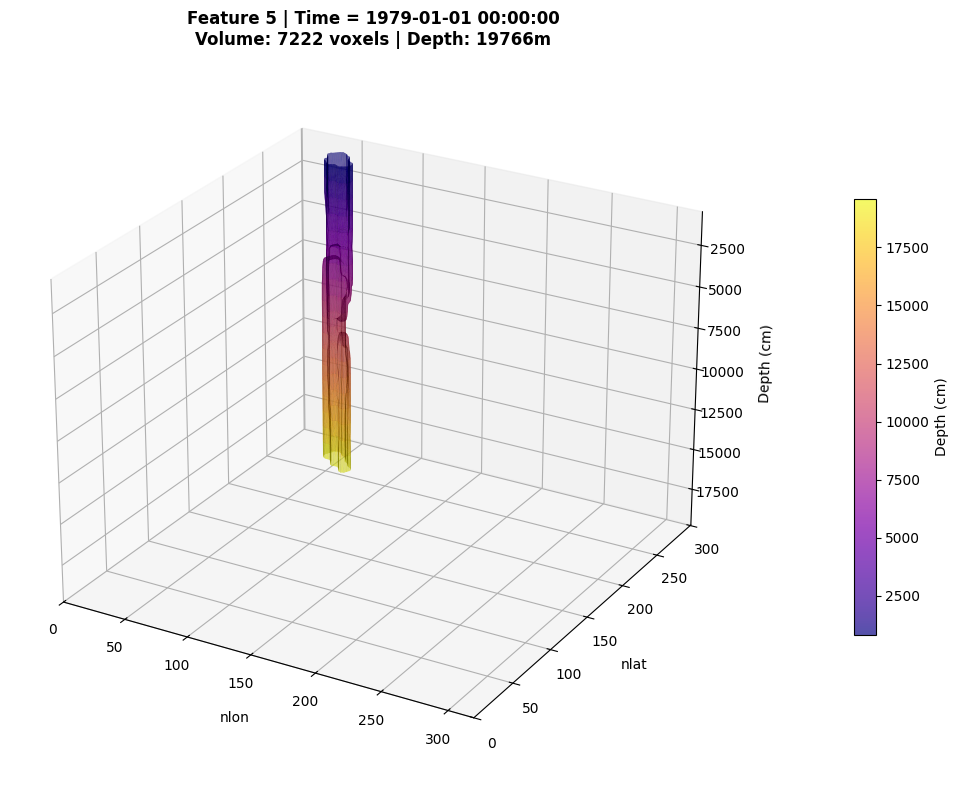


Plotting feature 5 at time 1
Applied Gaussian smoothing (sigma=0.5)
Extracted surface: 2997 vertices, 5794 faces


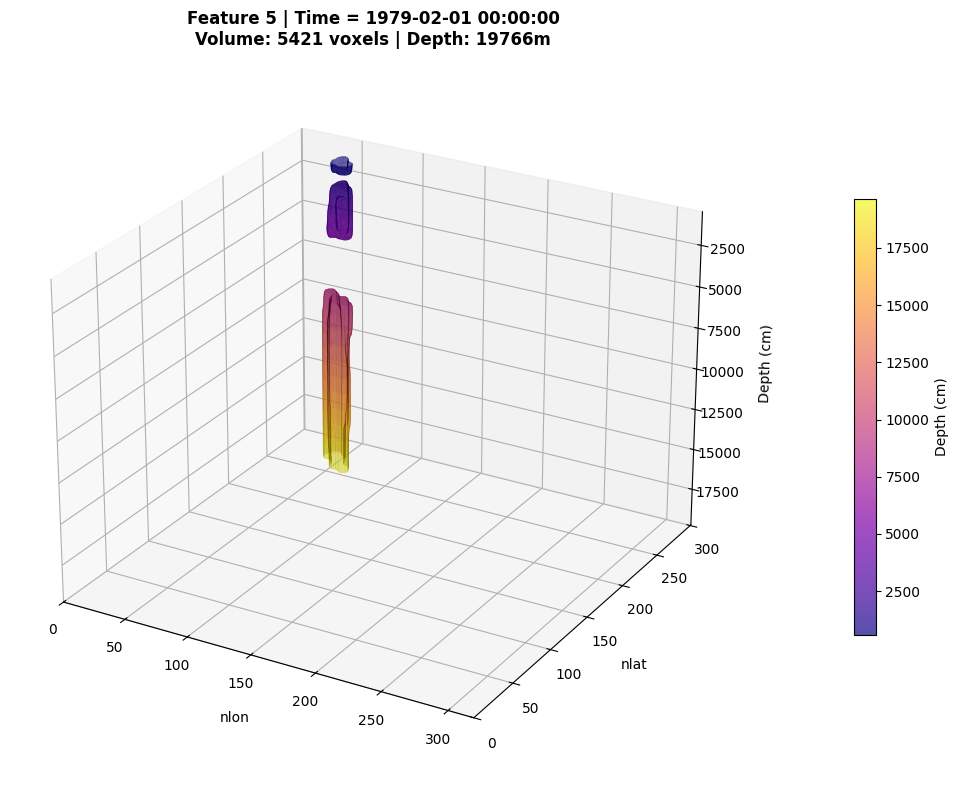


Plotting feature 5 at time 2
Applied Gaussian smoothing (sigma=0.5)
Extracted surface: 2934 vertices, 5654 faces


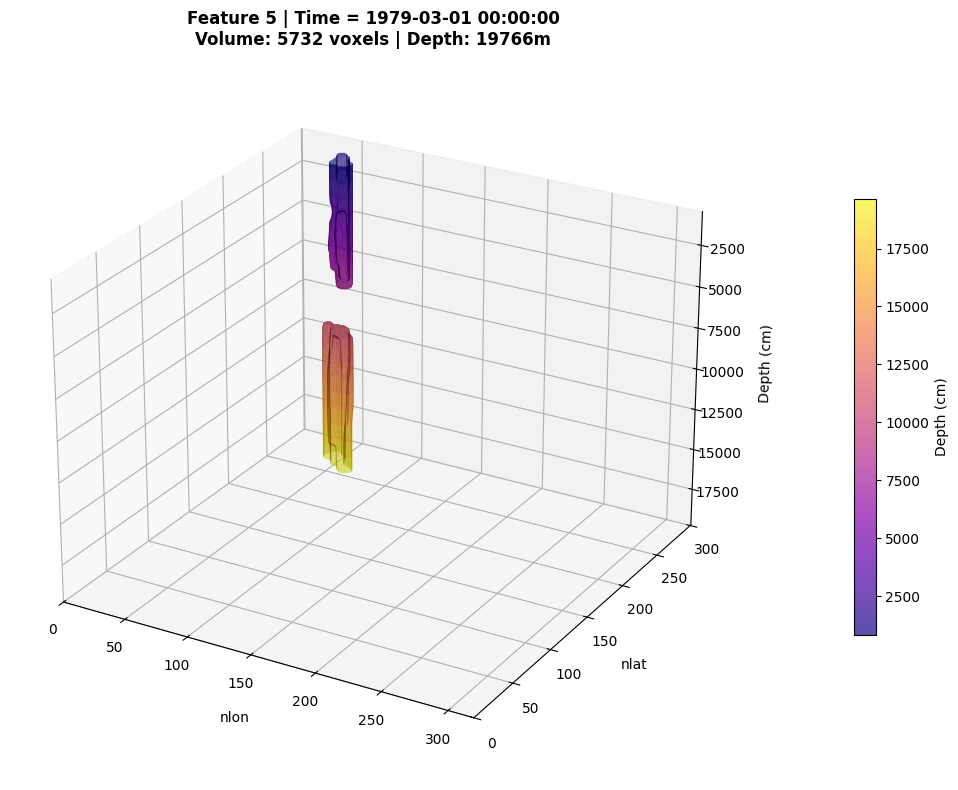

In [41]:
for time_idx in range(3):
    print(f"\n{'='*50}")
    print(f"Plotting feature 5 at time {time_idx}")
    print(f"{'='*50}")
    
    fig, ax = plot_3d_labeled_feature(
        result_xr, 
        feature_id=5, 
        time_idx=time_idx,
        threshold=0.5,
        sigma=0.5,  # Slight smoothing for cleaner surface
        alpha=0.7,
        cmap='plasma',
        elev=25,
        azim=-60,
        figsize=(12, 8)
    )
    
    if fig is not None:
        plt.show()
        plt.close(fig)


Plotting feature 1 at time 5
Applied Gaussian smoothing (sigma=0.2)
Extracted surface: 11367 vertices, 22190 faces


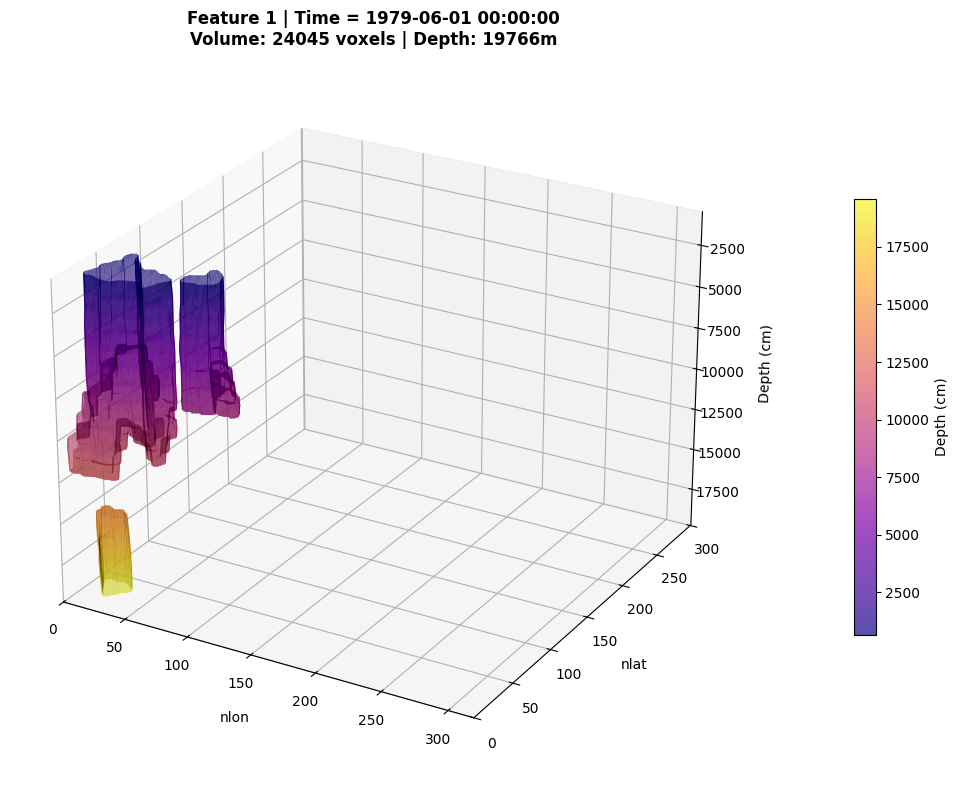


Plotting feature 1 at time 6
Applied Gaussian smoothing (sigma=0.2)
Extracted surface: 13798 vertices, 27170 faces


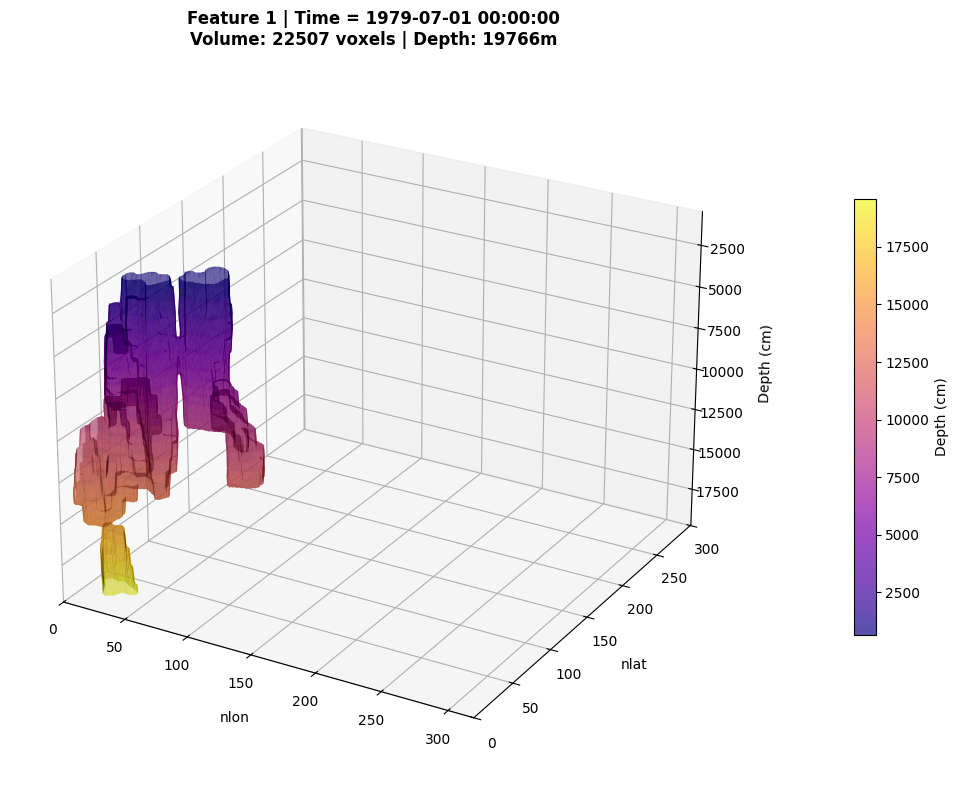


Plotting feature 1 at time 7
Applied Gaussian smoothing (sigma=0.2)
Extracted surface: 13880 vertices, 27280 faces


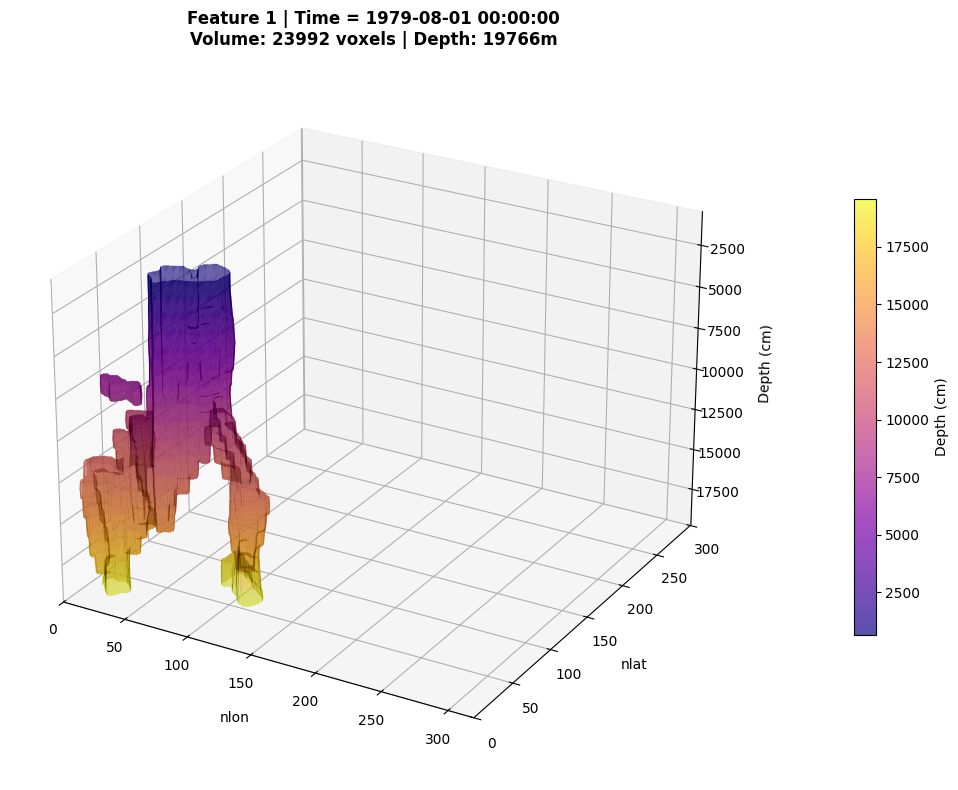

In [44]:
for time_idx in range(5,8):
    print(f"\n{'='*50}")
    print(f"Plotting feature 1 at time {time_idx}") # also 4 is interested
    print(f"{'='*50}")
    
    fig, ax = plot_3d_labeled_feature(
        result_xr, 
        feature_id=1, 
        time_idx=time_idx,
        threshold=0.5,
        sigma=0.2,  # Slight smoothing for cleaner surface
        alpha=0.7,
        cmap='plasma',
        elev=25,
        azim=-60,
        figsize=(12, 8)
    )
    
    if fig is not None:
        plt.show()
        plt.close(fig)